<a href="https://colab.research.google.com/github/joaopedrocosta2004/ISEC/blob/main/Mestrado/2%C2%BASemestre/AD2526_P2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Setup, Version check and Common imports

# Python ≥ 3.7 is required
import sys
assert sys.version_info >= (3, 7)


# TensorFlow ≥ 2.8 is required
import tensorflow as tf
from packaging import version

assert version.parse(tf.__version__) >= version.parse("2.8.0")

# Common imports
import numpy as np
import os

from tensorflow import keras
from tensorflow.keras import layers

import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

print('Python version: ', sys.version_info)
print('TF version: ', tf.__version__)
print('Keras version: ', keras.__version__)
print('GPU is', 'available' if tf.config.list_physical_devices('GPU') else 'NOT AVAILABLE')

Python version:  sys.version_info(major=3, minor=12, micro=12, releaselevel='final', serial=0)
TF version:  2.19.0
Keras version:  3.10.0
GPU is available


**1. Obtaining and Splitting the Dataset into 3 Sets (Train, Test, Validation)**


In [ ]:

# Load CIFAR100 dataset from keras datasets:
# https://keras.io/api/datasets/cifar100/
# https://www.cs.toronto.edu/~kriz/cifar.html

# The load_data() method creates train and test sets. The parameter label_mode specifies the category labels: 'fine' or 'coarse'
# In this class we will adopt the coarse classification, corresponding to 20 categories

from keras.datasets import cifar100
from sklearn.model_selection import train_test_split

(train_images_full, train_labels_full), (test_images, test_labels) = cifar100.load_data(label_mode = 'coarse')

train_labels_full = train_labels_full.squeeze()
test_labels = test_labels.squeeze()


# We further divide the original train datasets into train and validation datasets
train_images, valid_images, train_labels, valid_labels = train_test_split(
    train_images_full, train_labels_full,
    test_size=0.1,
    random_state=42,
    stratify=train_labels_full
)

# Normalize data to interval [0, 1]

train_images = train_images / 255.0
valid_images = valid_images / 255.0
test_images = test_images / 255.0


169001437/169001437 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [ ]:

# Complete this section
# Confirm the dimensions of all tensors previously created

# PLACE CODE HERE
print('Train')
print(train_images.shape)
print('\nValid')
print(valid_images.shape)
print('\nTest')
print(test_images.shape)


Train
(45000, 32, 32, 3)

Valid
(5000, 32, 32, 3)

Test
(10000, 32, 32, 3)


**Questions:**

1. What is the shape of the tensors? These dimensions correspond to what?
   R.: São os mencionados acima. O primeiro número corresponde aos conjunto de imagens disponiveis, o segundo e terceiro ao tamanho da imagem e o quarto ao RGB que são as 3 camadas.

2. How many elements does each of these sets have?
   R.: Para o train tem 45000 elementos, o de validação tem 5000 elementos e o de Teste tem 10000 elementos.

3. Why do we need three sets?
   R.: O primeiro set serve para treinar o modelo, o segundo set para validar durante o treino, e o terceiro set serve para testar depois do modelo ter sido treinado.

**2. Visualizing Some Examples**

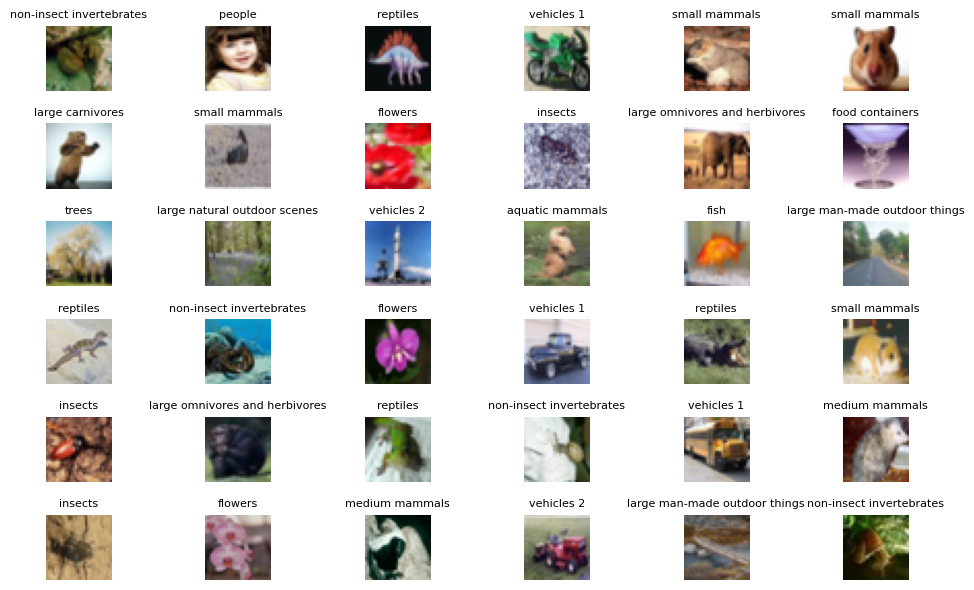

In [ ]:
# Visualize a few examples

coarse_names = [
    "aquatic mammals", "fish", "flowers", "food containers",
    "fruit and vegetables", "household electrical devices",
    "household furniture", "insects", "large carnivores",
    "large man-made outdoor things", "large natural outdoor scenes",
    "large omnivores and herbivores", "medium mammals",
    "non-insect invertebrates", "people", "reptiles",
    "small mammals", "trees", "vehicles 1", "vehicles 2"
]

n_rows = 6
n_cols = 6

# Change the value of start to visualize different examples
start = 0

plt.figure(figsize=(n_cols * 2, n_rows * 1.2))
for row in range(n_rows):
    for col in range(n_cols):
        index = n_cols * row + col
        plt.subplot(n_rows, n_cols, index + 1)
        plt.imshow(train_images[index + start])
        plt.axis('off')
        plt.title(coarse_names[train_labels[index + start]], fontsize=8)
plt.subplots_adjust(wspace=0.2, hspace=0.5)
plt.show()


**3. Linear Feed-Forward NN**

In [ ]:
# Build a feed-forward NN with Keras Sequential API: https://keras.io/api/models/

# This linear version does not have hidden layers
# 1. It has an input layer to receive information
# 2. It has final layer with the SoftMax activation function and the number of units should match the number of classes
# Complete the missing details:

keras.backend.clear_session()
tf.random.set_seed(42)
np.random.seed(42)

linearModel = keras.Sequential([
    # Input layer
    layers.Input(shape=[32,32,3]),
    layers.Flatten(),

    # No hidden layers

    # Final layer
    layers.Dense(20, activation='softmax')


])



**Question:**

Explain all the details of the NN that was just created:
1. Number of input nodes
   R.: 1
2. Number of output nodes
   R.: 20
3. Selection of activation functions
   R.: Softmax


In [ ]:
# Summary of the linear network architecture

linearModel.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 20)             │        61,460 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61,460 (240.08 KB)

 Trainable params: 61,460 (240.08 KB)

 Non-trainable params: 0 (0.00 B)

**Question:**

1. How many weights has the NN?

2. How were these weights initialized?



In [ ]:
# Model compilation: https://keras.io/api/models/model_training_apis/
# Three components have to be defined:
# 1. the Optimizer to be used in training
# 2. The loss function
# 3. The evaluation metric

linearModel.compile(loss="sparse_categorical_crossentropy",
              optimizer=keras.optimizers.SGD(),
              metrics=["accuracy"])



In [ ]:
# Model training
# Hyper-parameters: batch size and epochs
# Validation datasets can also be provided

# It returns a history object.
# Its History.history attribute is a record of training loss values and metrics values at successive epochs,
# as well as validation loss values and validation metrics values (if applicable).

history = linearModel.fit(train_images, train_labels, batch_size=32, epochs=20,
                    validation_data=(valid_images, valid_labels))



Epoch 1/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.1472 - loss: 2.7817 - val_accuracy: 0.1628 - val_loss: 2.8058
Epoch 2/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.2128 - loss: 2.5671 - val_accuracy: 0.1736 - val_loss: 2.7567
Epoch 3/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.2273 - loss: 2.5281 - val_accuracy: 0.1820 - val_loss: 2.7315
Epoch 4/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.2352 - loss: 2.5058 - val_accuracy: 0.1868 - val_loss: 2.7150
Epoch 5/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.2398 - loss: 2.4897 - val_accuracy: 0.1914 - val_loss: 2.7031
Epoch 6/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.2446 - loss: 2.4772 - val_accuracy: 0.1926 - val_loss: 2.6941
Epoch 7/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.2483 - loss: 2.4668 - val_accuracy: 0.1958 - val_loss: 2.6872
Epoch 8/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.2517 - loss: 2.4579 - 

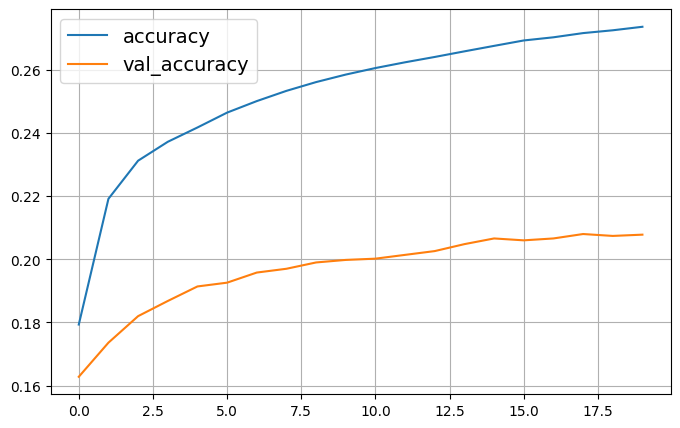

In [ ]:

# Plot the evolution of the accuracy metrics

import pandas as pd

x = pd.DataFrame(history.history, columns = ['accuracy', 'val_accuracy'])
x.plot(figsize=(8, 5))
plt.grid(True)
plt.show()



In [ ]:

# Evaluating the generalization ability of the linear model
# The test set will be used in this step
# Classification of a set of examples can be performed using the evaluate() method:  https://keras.io/api/models/model_training_apis/

test_loss, test_acc = linearModel.evaluate(test_images, test_labels)
print(f"Test Accuracy: {test_acc}")


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2098 - loss: 2.6484
Test Accuracy: 0.20669999718666077


**Questions:**

1. How do you analyze these results?

2. What is the difference between the validation and test datasets?



**4. Shallow Feed-forward NN**

In [ ]:
# Build a feed-forward NN with Keras Sequential API: https://keras.io/api/models/

# This shallow version has a single hidden layer
# 1. It has an input layer to receive information
# 2. It has one hidden layer with 128 units and sigmoid activation function
# 3. It has final layer with the SoftMax activation function and the number of units should match the number of classes

# Complete the missing details:

keras.backend.clear_session()
tf.random.set_seed(42)
np.random.seed(42)


shallowModel = keras.Sequential([
    # Input layer
    layers.Input(shape=[32,32,3]),
    layers.Flatten(),

    # One hidden layer
    layers.Dense(128, activation='sigmoid'),

    # Final layer
    layers.Dense(20, activation='softmax')

])




In [ ]:
# Summary of the shallow network architecture

shallowModel.summary()



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       393,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 20)             │         2,580 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 395,924 (1.51 MB)

 Trainable params: 395,924 (1.51 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Layer detailed analysis

hidden1 = shallowModel.layers[1]
weights, biases = hidden1.get_weights()

print('Layer ', hidden1.name)
print('Weights with shape ', weights.shape, ' :\n', weights)
print('Biases with shape ', biases.shape, ' :\n', biases)


Layer  dense
Weights with shape  (3072, 128)  :
 [[ 0.01422955 -0.02700842  0.03404783 ... -0.01601776 -0.03188717
   0.02294544]
 [ 0.03506905 -0.01204667 -0.01753471 ...  0.03438958  0.00261304
  -0.01736995]
 [ 0.02390809 -0.00096741  0.03985836 ...  0.03218188 -0.03282332
   0.04109918]
 ...
 [-0.009      -0.01674904 -0.01348272 ...  0.02542197  0.03619708
   0.00560263]
 [ 0.01152679 -0.01266768  0.00290391 ...  0.01156311 -0.00634082
  -0.01386445]
 [ 0.03384486  0.01556109 -0.03707251 ... -0.04271889  0.04026971
   0.02811694]]
Biases with shape  (128,)  :
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0.]


In [ ]:
# Shallow model compiling and training

shallowModel.compile(loss="sparse_categorical_crossentropy",
              optimizer=keras.optimizers.SGD(),
              metrics=["accuracy"])

history = shallowModel.fit(train_images, train_labels, batch_size=32, epochs=20,
                    validation_data=(valid_images, valid_labels))




Epoch 1/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.1174 - loss: 2.9031 - val_accuracy: 0.1832 - val_loss: 2.7128
Epoch 2/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.1954 - loss: 2.6786 - val_accuracy: 0.2040 - val_loss: 2.6229
Epoch 3/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.2124 - loss: 2.6003 - val_accuracy: 0.2230 - val_loss: 2.5735
Epoch 4/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.2249 - loss: 2.5531 - val_accuracy: 0.2320 - val_loss: 2.5388
Epoch 5/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.2344 - loss: 2.5187 - val_accuracy: 0.2400 - val_loss: 2.5129
Epoch 6/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.2426 - loss: 2.4924 - val_accuracy: 0.2420 - val_loss: 2.4929
Epoch 7/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.2479 - loss: 2.4716 - val_accuracy: 0.2448 - val_loss: 2.4768
Epoch 8/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.2531 - loss: 2.4545 - 

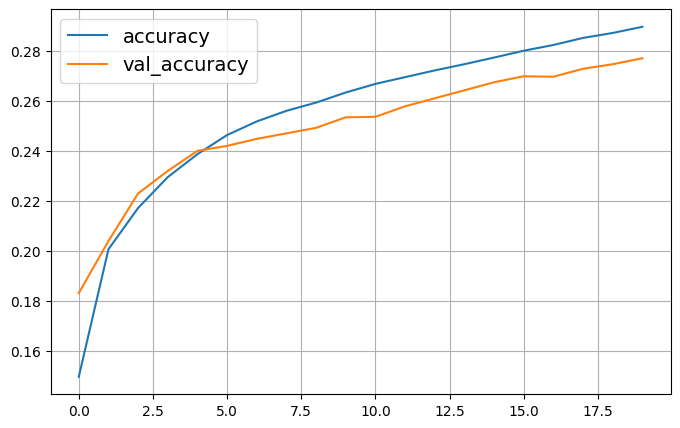

In [ ]:

x = pd.DataFrame(history.history, columns = ['accuracy', 'val_accuracy'])
x.plot(figsize=(8, 5))
plt.grid(True)
plt.show()


In [ ]:
# Evaluating the generalization ability of the shallow model
# The test set will be used in this step
# Classification of a set of examples can be performed using the evaluate() method:  https://keras.io/api/models/model_training_apis/

test_loss, test_acc = shallowModel.evaluate(test_images, test_labels)
print(f"Test Accuracy: {test_acc}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2768 - loss: 2.3755
Test Accuracy: 0.2752000093460083


**Question:**

1. How do you analyze these results?

**5. Deep Feed-forward NN**

In [ ]:
# Build a feed-forward NN with Keras Sequential API: https://keras.io/api/models/

# This deep version has two hidden layers
# 1. It has an input layer to receive information
# 2. The first hidden layer has 128 units with the sigmoid activation function
# 3. The second hidden layer has 64 units with the sigmoid activation function
# 3. It has final layer with the SoftMax activation function and the number of units should match the number of classes

# Complete the missing details:

keras.backend.clear_session()
tf.random.set_seed(42)
np.random.seed(42)


deepModel = keras.Sequential([
    layers.Input(shape=[32,32,3]),
    layers.Flatten(),

    # Two hidden layer
    layers.Dense(128, activation='sigmoid'),
    layers.Dense(64, activation='sigmoid'),

    # Final layer
    layers.Dense(20, activation='softmax'),


])


In [ ]:
# Summary of the deep network architecture

deepModel.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       393,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 20)             │         1,300 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 402,900 (1.54 MB)

 Trainable params: 402,900 (1.54 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Deep model compiling and training

deepModel.compile(loss="sparse_categorical_crossentropy",
              optimizer=keras.optimizers.SGD(),
              metrics=["accuracy"])



history = deepModel.fit(train_images, train_labels, batch_size=32, epochs=20,
                    validation_data=(valid_images, valid_labels))


Epoch 1/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.0699 - loss: 3.0004 - val_accuracy: 0.1276 - val_loss: 2.9547
Epoch 2/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.1415 - loss: 2.9432 - val_accuracy: 0.1586 - val_loss: 2.8984
Epoch 3/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.1589 - loss: 2.8798 - val_accuracy: 0.1648 - val_loss: 2.8188
Epoch 4/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.1632 - loss: 2.7995 - val_accuracy: 0.1716 - val_loss: 2.7505
Epoch 5/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.1679 - loss: 2.7365 - val_accuracy: 0.1746 - val_loss: 2.7052
Epoch 6/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.1735 - loss: 2.6950 - val_accuracy: 0.1804 - val_loss: 2.6740
Epoch 7/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.1790 - loss: 2.6656 - val_accuracy: 0.1878 - val_loss: 2.6499
Epoch 8/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.1866 - loss: 2.6419 - 

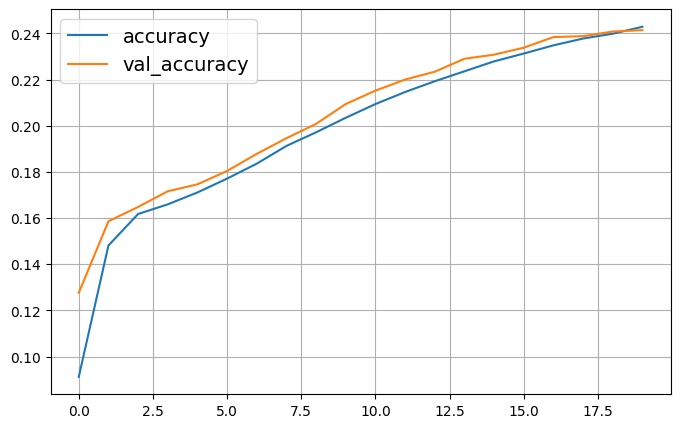

In [ ]:

x = pd.DataFrame(history.history, columns = ['accuracy', 'val_accuracy'])
x.plot(figsize=(8, 5))
plt.grid(True)
plt.show()


In [ ]:
# Evaluating the generalization ability of the deep model
# The test set will be used in this step
# Classification of a set of examples can be performed using the evaluate() method:  https://keras.io/api/models/model_training_apis/

test_loss, test_acc = deepModel.evaluate(test_images, test_labels)
print(f"Test Accuracy: {test_acc}")


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2372 - loss: 2.4787
Test Accuracy: 0.23720000684261322


**Question:**

1. Analyze and compare all results that were obtained with the three models

**6. Model Saving**

In [ ]:
# Save the model. All models details (architecture, configuration, weights) can be saved to disk.
# The method save creates a folder with all the information

deepModel.save("Modelo_Aula2.keras")

# The model can be later retrieved with the method load_model()


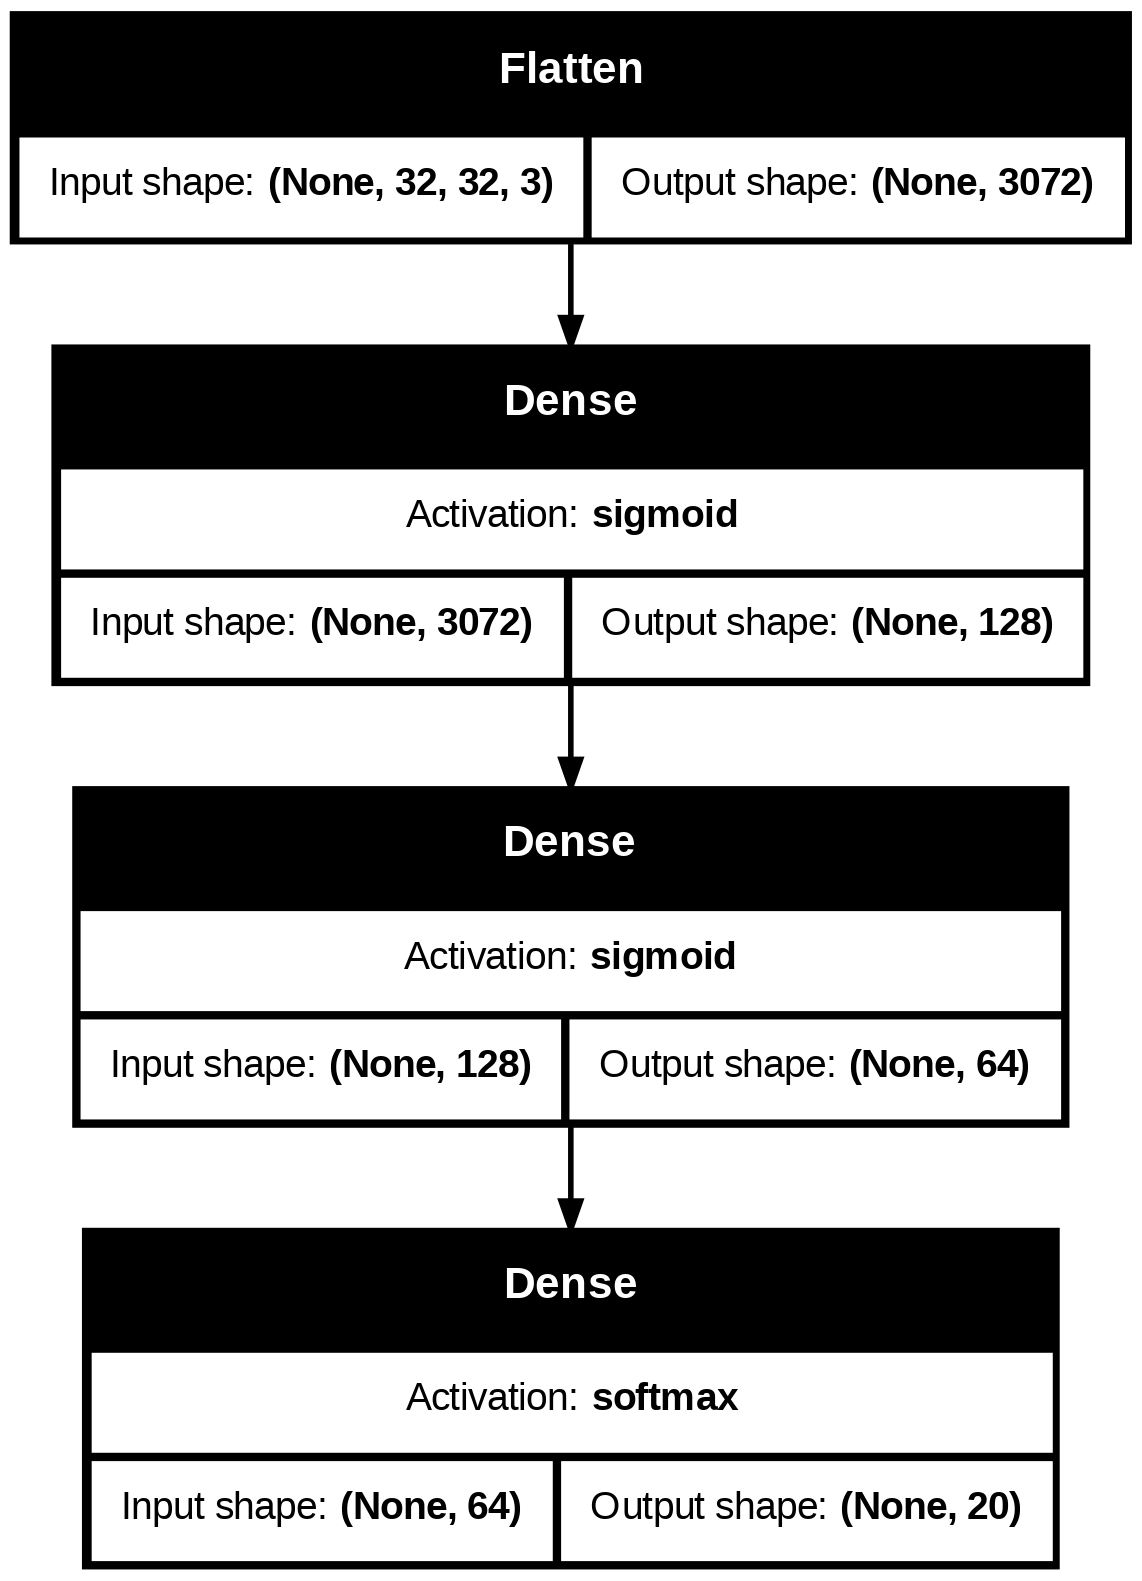

In [ ]:
# Convert model to png and save it to a file

dot_img_file = 'deep.png'
keras.utils.plot_model(deepModel, to_file=dot_img_file, show_shapes=True, show_layer_activations=True)



**7. Changes in the Architecture of the Neural Network**

The performance of the neural network is poor. It is mandatory to perform changes, aiming at improving its performance. There are several possibilities that can be tested:

The proposed neural network may not be the most suitable for this problem. Change its architecture (number of layers / number of neurons per layer) and document how performance changes. The following constraints apply:
  *    The Keras Sequential API must be used
  *    Only Flatten and Dense layers can be used
  *    Activation functions: Sigmoid, Tanh, SoftMax
  *    Optimizer: SGD
  *    Budget: 2 million weights

Perform some tests, document how results change and present a simple analysis of the outcome.

Your target is to achieve 35% accuracy on the test dataset







In [ ]:
# Code goes here

keras.backend.clear_session()
tf.random.set_seed(42)
np.random.seed(42)

newModel = keras.Sequential([
    # Input layer


    # Hidden layers


    # Final layer


])

# Compile



# Train



# Evaluate


